In [5]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt
from typing import List, Dict, Any, Literal

BENCHMARK_FILE_MODE: Literal["all_files", "latest_file"] = "all_files"
""" Whether load and merge all benchmark files or use only latest one """

def list_benchmark_files() -> List[Path]:
    """ List all benchmark files sorted by datetime (desc) """

    benchmarks_dirs = list(Path('.').glob('**/.benchmarks'))
    json_files = []
    for bench_dir in benchmarks_dirs:
        json_files.extend(bench_dir.glob('**/*.json'))

    json_files.sort(key=lambda x: x.stat().st_mtime, reverse=True)

    if not json_files:
        raise ValueError("No benchmark data loaded!")
    
    return json_files

def load_benchmark_file(file: Path) -> pd.DataFrame:
    """ Load single benchmark file and extract the data into DataFrame"""
    content = json.loads(file.read_text())
    return extract_benchmark_data(content).assign(run_id=int(file.name.split("_")[0]))

def extract_benchmark_data(benchmark_data: Dict[str, Any]) -> pd.DataFrame:
    """ Extract benchmark data into DataFrame """
    benchmarks = benchmark_data.get('benchmarks', [])

    # Extract data for each benchmark entry
    records = []
    for bench in benchmarks:
        test_name: str = bench["name"]

        test_file, _, run_name = test_name.partition("[")
        agent_name = "_".join(test_file.split("_")[1:3])
        model_name, query_number = run_name.strip("]").rsplit("-", 1)
        query_number = int(query_number)
        
        # Get execution times and run statuses
        execution_times = bench.get('stats', {}).get('data', [])
        run_statuses = bench.get('extra_info', {}).get('run_status', [])
        
        # Each benchmark entry has multiple runs
        for i, exec_time in enumerate(execution_times):
            status = run_statuses[i] if i < len(run_statuses) else "UNKNOWN"
            records.append({
                'agent': agent_name,
                'model': model_name,
                'query_number': query_number,
                'execution_time': exec_time,
                'status': status,
                'is_success': not status.startswith("ERROR"),
            })

    # Create DataFrame
    return pd.DataFrame(records)

def load_and_merge_benchmark_files(files: List[Path]) -> pd.DataFrame:
    """ Load multiple benchmark files and merge them to a frame """
    df = pd.concat([load_benchmark_file(f) for f in files], axis=0)

    df["index"] = df \
        .groupby(["agent", "model", "query_number", "run_id"]) \
        ["execution_time"] \
        .transform(lambda x: np.arange(len(x)))

    df = df \
        .sort_values(["agent", "model", "query_number", "index", "run_id"]) \
        .drop_duplicates(["agent", "model", "query_number", "index"], keep="last") \
        .drop(columns=["index"]) \
        .query("model != 'deepseek-reasoner'")
    
    return df

In [6]:
files = list_benchmark_files()

match BENCHMARK_FILE_MODE:
    case "latest_file":
        df = load_benchmark_file(files[0])
    case "all_files":
        df = load_and_merge_benchmark_files(files)

df.sample(10)

,agent,model,query_number,execution_time,status,is_success,run_id
103,bsl_agent,qwen3:30b,2,4.431393,PASSED,True,8
13,bsl_agent,deepseek-chat,1,8.506210,PASSED,True,10
1,sql_agent,deepseek-chat,2,54.694235,PASSED,True,5
21,bsl_agent,gpt-oss:20b,1,8.677512,PASSED,True,8
55,sql_agent,gpt-oss:20b,2,20.229977,PASSED,True,3
98,bsl_agent,qwen3:30b,2,5.677540,PASSED,True,8
2,sql_agent,deepseek-chat,2,53.562800,PASSED,True,5
34,bsl_agent,gpt-oss:20b,2,37.252518,PASSED,True,8
8,sql_agent,gpt-oss:20b,1,13.884140,PASSED,True,3
84,bsl_agent,qwen3:30b,1,3.202471,ERROR: Result data does not match expected data,False,8


In [7]:
# Calculate statistics per agent / model

df_success = df[df["is_success"]]
print(f"Total runs: {len(df)}")
print(f"Successful runs: {len(df_success)}")
print(f"Failed runs: {len(df) - len(df_success)}")

stats = df_success \
    .groupby(['agent', 'model'], as_index=False) \
    .agg(
        min=pd.NamedAgg('execution_time','min'),
        max=pd.NamedAgg('execution_time','max'),
        mean=pd.NamedAgg('execution_time','mean'),
        std=pd.NamedAgg('execution_time','std')
    )

accuracy = df \
    .groupby(['agent', 'model'], as_index=False) \
    .agg(
        total_runs=pd.NamedAgg('status','count'),
        successful_runs=pd.NamedAgg('is_success', 'sum'),
    ) \
    .assign(accuracy = lambda df: df['successful_runs'] / df['total_runs'])

stats_table = pd.merge(stats, accuracy, on=["agent", "model"])
stats_table

Total runs: 360
Successful runs: 294
Failed runs: 66


,agent,model,min,max,mean,std,total_runs,successful_runs,accuracy
0,bsl_agent,deepseek-chat,7.614995,155.819387,12.413399,20.818959,60,60,1.000000
1,bsl_agent,gpt-oss:20b,1.542793,37.252518,9.313750,6.741287,60,59,0.983333
2,bsl_agent,qwen3:30b,4.427134,15.334803,5.983641,2.980370,60,30,0.500000
3,sql_agent,deepseek-chat,31.421389,77.970481,45.014009,8.539996,60,57,0.950000
4,sql_agent,gpt-oss:20b,0.476421,35.434607,14.292459,6.129893,60,53,0.883333
5,sql_agent,qwen3:30b,5.767421,78.090503,45.531017,15.102127,60,35,0.583333


,agent,model,min,max,mean,std,total_runs,successful_runs,accuracy
5,sql_agent,qwen3:30b,5.767421,78.090503,45.531017,15.102127,60,35,0.583333
2,bsl_agent,qwen3:30b,4.427134,15.334803,5.983641,2.980370,60,30,0.500000
4,sql_agent,gpt-oss:20b,0.476421,35.434607,14.292459,6.129893,60,53,0.883333
1,bsl_agent,gpt-oss:20b,1.542793,37.252518,9.313750,6.741287,60,59,0.983333
3,sql_agent,deepseek-chat,31.421389,77.970481,45.014009,8.539996,60,57,0.950000
0,bsl_agent,deepseek-chat,7.614995,155.819387,12.413399,20.818959,60,60,1.000000


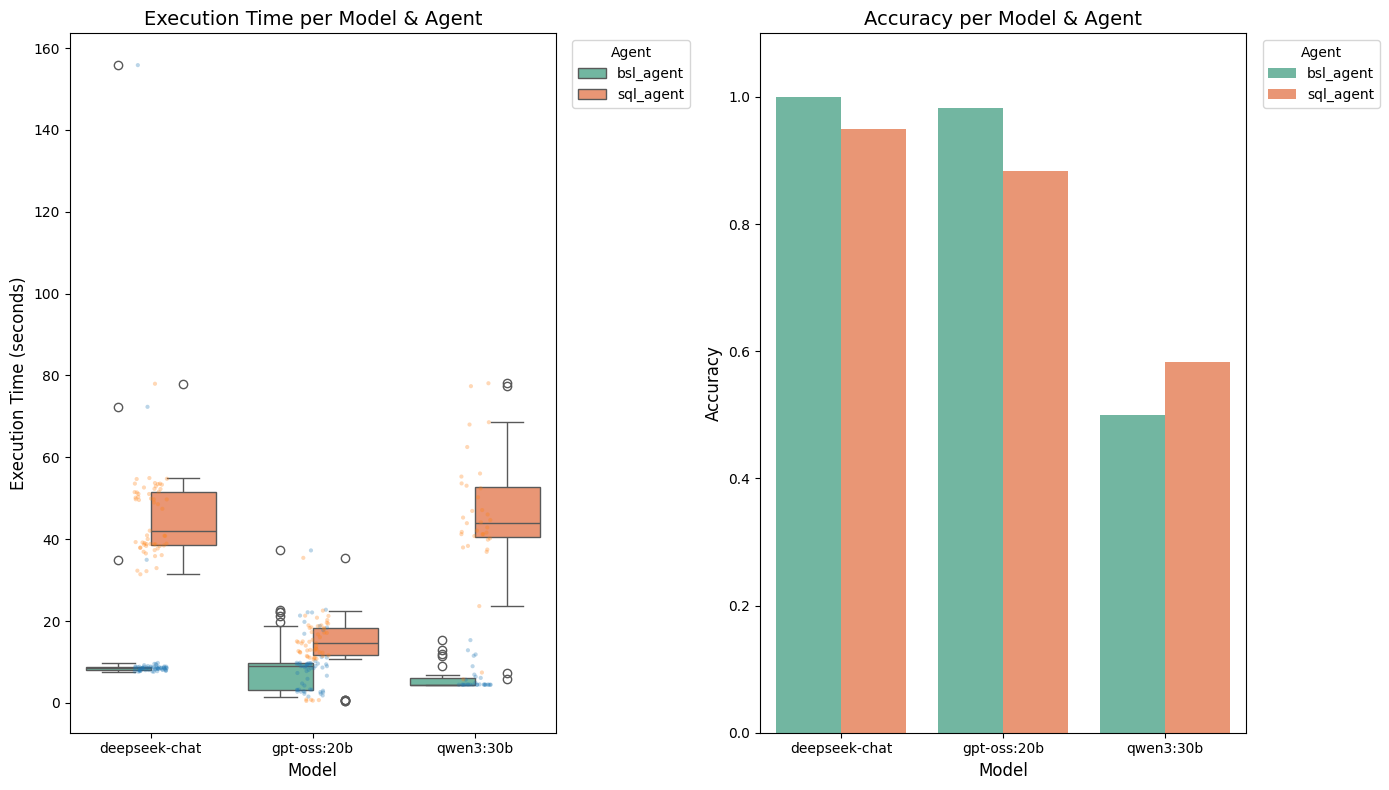

In [8]:
# Display stats table
display(stats_table.sort_values(["model", "agent"], ascending=False))

# Execution time
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

ax1 = axes[0]
boxes = sns.boxplot(data=df_success, x='model', y='execution_time', hue="agent", ax=ax1, palette='Set2')

ax1.set_title('Execution Time per Model & Agent', fontsize=14)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
ax1.legend(title='Agent', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add individual data points
sns.stripplot(data=df_success, x='model', y='execution_time', hue='agent', ax=ax1, alpha=0.3, size=3, dodge=False, legend=False)

# Display bar diagram of accuracy - grouped by model and agent
ax2 = axes[1]
accuracy_sorted = stats_table.sort_values(['model', 'agent'], ascending=True)

# Create grouped bar chart with model on x-axis and agent as hue
bars = sns.barplot(data=accuracy_sorted, x='model', y='accuracy', hue='agent', ax=ax2, palette='Set2')

ax2.set_title('Accuracy per Model & Agent', fontsize=14)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.legend(title='Agent', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add value labels on bars
# for container in bars.containers:
#     bars.bar_label(container, fmt='%.0f%%', fontsize=8)

plt.tight_layout()
plt.show()